# Week 1-2

Filename: /Users/ariftushar/astropy_run_Su26/Week 1+2/lm_260429_000152.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     176   (2048, 2048, 30)   int16 (rescales to uint16)   


Filename: /Users/ariftushar/astropy_run_Su26/Week 1+2/lm_260429_000162.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     176   (2048, 2048, 30)   int16 (rescales to uint16)   
<class 'numpy.ndarray'>
(2048, 2048)
<class 'numpy.ndarray'>
(2048, 2048)
Min: 0
Max: 4095
Mean: 579.3363807201385
Stdev: 123.76161431724938
Min: 0
Max: 4095
Mean: 499.8654592037201
Stdev: 128.64032183565303


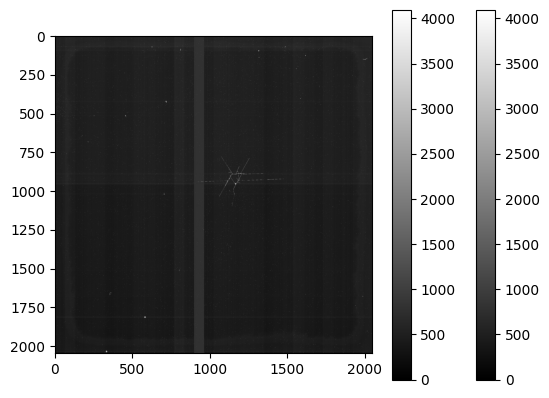

In [5]:
import numpy as np

# setting up matplotlib
import matplotlib.pyplot as plt

#importing FITS
from astropy.io import fits

#opening my 1st FITS file
hdu_list_1 = fits.open("/Users/ariftushar/astropy_run_Su26/Week 1+2/lm_260429_000152.fits")
hdu_list_1.info()
#extracting image data from the 1st FITS file
image_data_1 = hdu_list_1[0].data[0]

#opening my 2nd FITS file
hdu_list_2 = fits.open("/Users/ariftushar/astropy_run_Su26/Week 1+2/lm_260429_000162.fits")
hdu_list_2.info()
#extracting image data from the 2nd FITS file
image_data_2 = hdu_list_2[0].data[0]

#print your data extractions
print(type(image_data_1))
print(image_data_1.shape)
print(type(image_data_2))
print(image_data_2.shape)

#plot & view the 1st file
plt.imshow(image_data_1, cmap="gray")
plt.colorbar()

#plot & view the 2nd file
plt.imshow(image_data_2, cmap="gray")
plt.colorbar()

#print basic stats of 1st file
print("Min:", np.min(image_data_1))
print("Max:", np.max(image_data_1))
print("Mean:", np.mean(image_data_1))
print("Stdev:", np.std(image_data_1))

#print basic stats of 2nd file
print("Min:", np.min(image_data_2))
print("Max:", np.max(image_data_2))
print("Mean:", np.mean(image_data_2))
print("Stdev:", np.std(image_data_2))

# Compute the difference image
diff_data = image_data_1 - image_data_2

# Create a new Primary HDU object with the difference data
# Copy the header from the first image to retain metadata
diff_hdu = fits.PrimaryHDU(data=diff_data, header=hdu_list_1[0].header)

# Save the difference to a new FITS file
diff_hdu.writeto('difference_152_162.fits', overwrite=True)

#to prevent crashing your device, close the file(s)
hdu_list_1.close()
hdu_list_2.close()

# Week 3

In [ ]:
### will be added this weekend (June 5- June 7)

# Week 4

## Mean "Super" Dark Frame

(2, 2048, 2048)


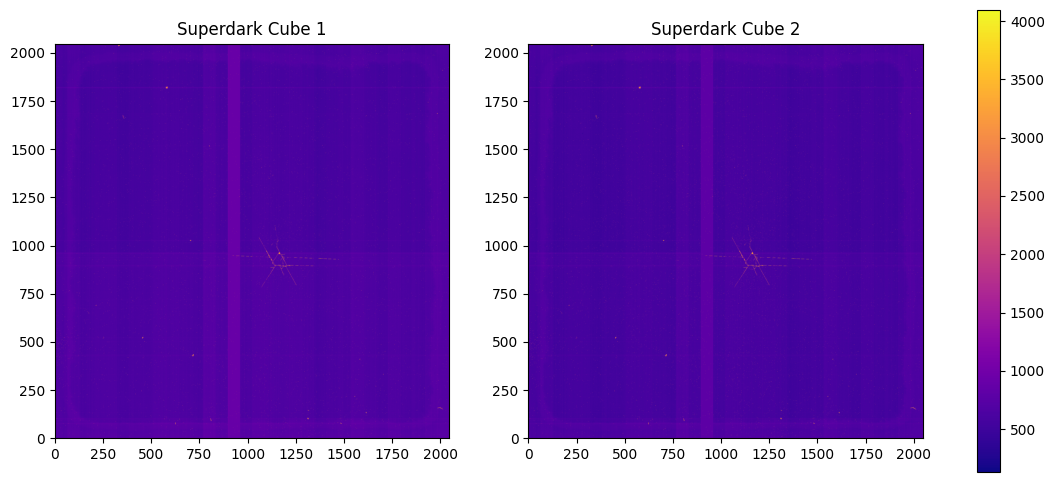

In [8]:
import numpy as np

# setting up matplotlib
import matplotlib.pyplot as plt

# importing fits
from astropy.io import fits

import glob

# call all the "dark" files 
dist_d_fnames = glob.glob('/Users/ariftushar/Downloads/LBTi APR 29, 2026 Data/51to100_Darks/*')

# extract data into a SEPARATE variable for the 3D NumPy array
dist_d_frames = np.array([fits.getdata(filename) for filename in dist_d_fnames])

# create the mean dark image using the frames array
dist_sd = np.average(dist_d_frames, axis=0)
print(dist_sd.shape)

# extract the header of the first dark frame using the filename string
info_dist_d = fits.getheader(dist_d_fnames[0])

# copy the header and add reduction notes
sd_hdr = info_dist_d.copy()  # Using .copy() protects your original file data structure
sd_hdr["Reduct"] = "Averaging 50 frames with exposure of 0.302s each"

# write the mean dark image data with updated header to a new FITS file
mean_dark = fits.PrimaryHDU(data=dist_sd, header=sd_hdr)
mean_dark.writeto("/Users/ariftushar/astropy_run_Su26/Week 4.fits", overwrite=True)

# load the super dark image data
sd_path = "/Users/ariftushar/astropy_run_Su26/Week 4.fits"
sd_idata = fits.getdata(sd_path)

# count the number of data cubes (frames) inside the file
num_cubes = sd_idata.shape[0]

# automatically set up side-by-side subplots matching the number of cubes
fig, axes = plt.subplots(1, num_cubes, figsize=(7 * num_cubes, 8))

# loop through and plot each 2D image slice dynamically
for idx in range(num_cubes):
    im = axes[idx].imshow(sd_idata[idx], origin="lower", cmap="plasma")
    axes[idx].set_title(f"Superdark Cube {idx+1}", size=12)

# shared colorbar scale applied across all subplots
fig.colorbar(im, ax=axes.tolist(), shrink=0.75, aspect=20, pad=0.05)

# display the figure 
plt.show()

## Normalized Mean Pseudo-flat

(2, 2048, 2048)


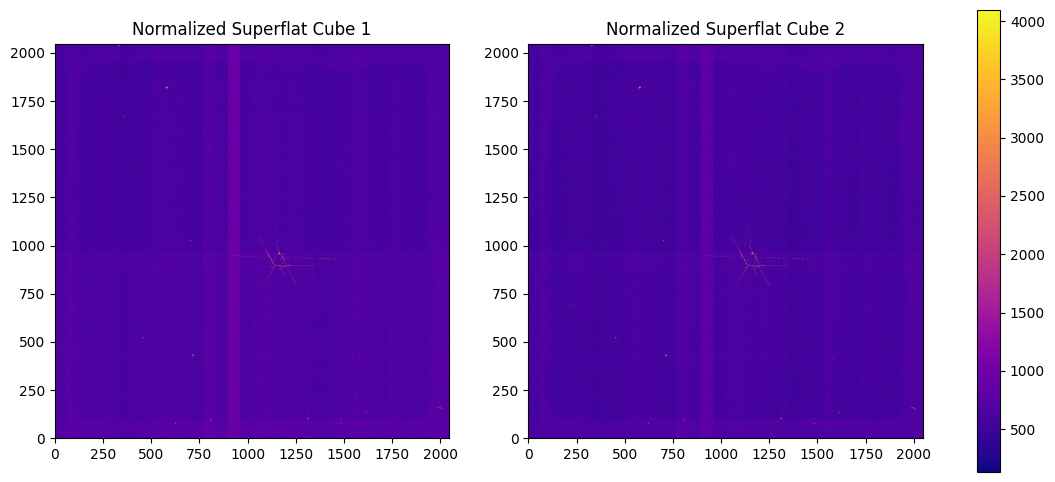

In [12]:
import numpy as np

# setting up matplotlib
import matplotlib.pyplot as plt

# importing fits
from astropy.io import fits
import glob

# call in all file names for pseudo-flat images
dist_pf_fnames = glob.glob('/Users/ariftushar/Downloads/LBTi APR 29, 2026 Data/101to150_PseudoFlat/*')

# extract data from all dark frames and convert directly into a 3D NumPy array
dist_pf_frames = np.array([fits.getdata(filename) for filename in dist_pf_fnames])

# create the normalized mean pseudo-flat image
dist_sf = np.average(dist_pf_frames,axis=0)
dist_norm_sf = (dist_sf - dist_sd) / np.median(dist_sf - dist_sd)
print(dist_norm_sf.shape)

# extract the header of the first pseudo-flat frame
info_dist_norm_sf = fits.getheader(dist_pf_fnames[0])

# add reduction notes to header
norm_sf_hdr = fits.Header()
norm_sf_hdr = info_dist_norm_sf
norm_sf_hdr["Reduct"] = "Averaging 50 frames with exposure of 0.302s each"

# write the mean dark image data with updated header to a new FITS file
normalized_mean_flat = fits.PrimaryHDU(data = dist_norm_sf, header = norm_sf_hdr)
mean_dark.writeto("/Users/ariftushar/astropy_run_Su26/Week 4.fits", overwrite=True)

# load normalized superflat data and headers
norm_sf_path = "/Users/ariftushar/astropy_run_Su26/Week 4.fits"
norm_sf_idata = fits.getdata(norm_sf_path)
norm_sf_iheaders = fits.getheader(norm_sf_path)

# count the number of frames (cubes)
num_cubes = norm_sf_idata.shape[0]

# setup the side-by-side subplot layout
fig, axes = plt.subplots(1, num_cubes, figsize=(7 * num_cubes, 8))

# loop through and plot each 2D slice
for idx in range(num_cubes):
    im = axes[idx].imshow(norm_sf_idata[idx], origin="lower", cmap="plasma")
    axes[idx].set_title(f"Normalized Superflat Cube {idx+1}", size=12)

# add shared colorbar positioned outside the plots
fig.colorbar(im, ax=axes.tolist(), shrink=0.75, aspect=20, pad=0.05)

# display the figure
plt.show()

## Reduction of Distortion Data

In [ ]:
a